In [13]:
# Install pandas for data manipulation
pip install pandas

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: C:\Users\DELL\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [15]:
# Install libraries for visualisation and machine learning
pip install matplotlib seaborn scikit-learn

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: C:\Users\DELL\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [16]:
import pandas as pd

# Load the dataset from CSV into a pandas DataFrame
df = pd.read_csv(r"C:\Users\DELL\Desktop\archive\KaggleV2-May-2016.csv")

# Preview the first few rows
print(df.head())

      PatientId  AppointmentID Gender          ScheduledDay  \
0  2.987250e+13        5642903      F  2016-04-29T18:38:08Z   
1  5.589978e+14        5642503      M  2016-04-29T16:08:27Z   
2  4.262962e+12        5642549      F  2016-04-29T16:19:04Z   
3  8.679512e+11        5642828      F  2016-04-29T17:29:31Z   
4  8.841186e+12        5642494      F  2016-04-29T16:07:23Z   

         AppointmentDay  Age      Neighbourhood  Scholarship  Hipertension  \
0  2016-04-29T00:00:00Z   62    JARDIM DA PENHA            0             1   
1  2016-04-29T00:00:00Z   56    JARDIM DA PENHA            0             0   
2  2016-04-29T00:00:00Z   62      MATA DA PRAIA            0             0   
3  2016-04-29T00:00:00Z    8  PONTAL DE CAMBURI            0             0   
4  2016-04-29T00:00:00Z   56    JARDIM DA PENHA            0             1   

   Diabetes  Alcoholism  Handcap  SMS_received No-show  
0         0           0        0             0      No  
1         0           0        0      

In [17]:
# Check the shape (rows, columns), preview data, column types, and missing values
print(df.shape)
print(df.head())
print(df.info())
print(df.isnull().sum())

(110527, 14)
      PatientId  AppointmentID Gender          ScheduledDay  \
0  2.987250e+13        5642903      F  2016-04-29T18:38:08Z   
1  5.589978e+14        5642503      M  2016-04-29T16:08:27Z   
2  4.262962e+12        5642549      F  2016-04-29T16:19:04Z   
3  8.679512e+11        5642828      F  2016-04-29T17:29:31Z   
4  8.841186e+12        5642494      F  2016-04-29T16:07:23Z   

         AppointmentDay  Age      Neighbourhood  Scholarship  Hipertension  \
0  2016-04-29T00:00:00Z   62    JARDIM DA PENHA            0             1   
1  2016-04-29T00:00:00Z   56    JARDIM DA PENHA            0             0   
2  2016-04-29T00:00:00Z   62      MATA DA PRAIA            0             0   
3  2016-04-29T00:00:00Z    8  PONTAL DE CAMBURI            0             0   
4  2016-04-29T00:00:00Z   56    JARDIM DA PENHA            0             1   

   Diabetes  Alcoholism  Handcap  SMS_received No-show  
0         0           0        0             0      No  
1         0           0  

In [18]:
# Confirm there are no missing values in any column
df.isnull().sum()

PatientId         0
AppointmentID     0
Gender            0
ScheduledDay      0
AppointmentDay    0
Age               0
Neighbourhood     0
Scholarship       0
Hipertension      0
Diabetes          0
Alcoholism        0
Handcap           0
SMS_received      0
No-show           0
dtype: int64

In [40]:
# View all column names before renaming
df.columns

Index(['PatientId', 'AppointmentID', 'Gender', 'ScheduledDay',
       'AppointmentDay', 'Age', 'Neighbourhood', 'Scholarship', 'Hypertension',
       'Diabetes', 'Alcoholism', 'Handicap', 'SMS_received', 'No_show',
       'WaitingDays', 'AgeGroup'],
      dtype='str')

In [41]:
# Fix typos in column names from the original dataset
df = df.rename(columns={
    "Hipertension": "Hypertension",
    "Handcap": "Handicap",
    "No-show": "No_show"
})

# Confirm the column names are now correct
df.columns

Index(['PatientId', 'AppointmentID', 'Gender', 'ScheduledDay',
       'AppointmentDay', 'Age', 'Neighbourhood', 'Scholarship', 'Hypertension',
       'Diabetes', 'Alcoholism', 'Handicap', 'SMS_received', 'No_show',
       'WaitingDays', 'AgeGroup'],
      dtype='str')

In [42]:
# Convert date columns from string to proper datetime format
df["ScheduledDay"] = pd.to_datetime(df["ScheduledDay"])
df["AppointmentDay"] = pd.to_datetime(df["AppointmentDay"])

# Confirm the data types are now datetime
df[["ScheduledDay", "AppointmentDay"]].dtypes

ScheduledDay      datetime64[us, UTC]
AppointmentDay    datetime64[us, UTC]
dtype: object

In [43]:
# Remove impossible age values — no one is older than 101 or younger than 1
df = df[df["Age"] < 102]
df = df[df["Age"] > 0]

In [44]:
# Calculate how many days between booking and the appointment
df["WaitingDays"] = (
    df["AppointmentDay"] - df["ScheduledDay"]
).dt.days

In [45]:
# Check all column names after adding WaitingDays
df.columns

Index(['PatientId', 'AppointmentID', 'Gender', 'ScheduledDay',
       'AppointmentDay', 'Age', 'Neighbourhood', 'Scholarship', 'Hypertension',
       'Diabetes', 'Alcoholism', 'Handicap', 'SMS_received', 'No_show',
       'WaitingDays', 'AgeGroup'],
      dtype='str')

In [46]:
# Display the full DataFrame to inspect the data
df

,PatientId,AppointmentID,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,Scholarship,Hypertension,Diabetes,Alcoholism,Handicap,SMS_received,No_show,WaitingDays,AgeGroup
5,9.598513e+13,5626772,F,2016-04-27 08:36:51+00:00,2016-04-29 00:00:00+00:00,76,REPÚBLICA,0,1,0,0,0,0,No,1,66+
6,7.336882e+14,5630279,F,2016-04-27 15:05:12+00:00,2016-04-29 00:00:00+00:00,23,GOIABEIRAS,0,0,0,0,0,0,Yes,1,19-35
7,3.449833e+12,5630575,F,2016-04-27 15:39:58+00:00,2016-04-29 00:00:00+00:00,39,GOIABEIRAS,0,0,0,0,0,0,Yes,1,36-50
9,7.812456e+13,5629123,F,2016-04-27 12:48:25+00:00,2016-04-29 00:00:00+00:00,19,CONQUISTA,0,0,0,0,0,0,No,1,19-35
10,7.345362e+14,5630213,F,2016-04-27 14:58:11+00:00,2016-04-29 00:00:00+00:00,30,NOVA PALESTINA,0,0,0,0,0,0,No,1,19-35
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
110522,2.572134e+12,5651768,F,2016-05-03 09:15:35+00:00,2016-06-07 00:00:00+00:00,56,MARIA ORTIZ,0,0,0,0,0,1,No,34,51-65
110523,3.596266e+12,5650093,F,2016-05-03 07:27:33+00:00,2016-06-07 00:00:00+00:00,51,MARIA ORTIZ,0,0,0,0,0,1,No,34,51-65
110524,1.557663e+13,5630692,F,2016-04-27 16:03:52+00:00,2016-06-07 00:00:00+00:00,21,MARIA ORTIZ,0,0,0,0,0,1,No,40,19-35
110525,9.213493e+13,5630323,F,2016-04-27 15:09:23+00:00,2016-06-07 00:00:00+00:00,38,MARIA ORTIZ,0,0,0,0,0,1,No,40,36-50


In [47]:
# Remove rows where waiting time is negative (data entry errors)
df = df[df["WaitingDays"] >= 0]

# Remove any fully duplicate rows
df = df.drop_duplicates()

In [49]:
# Calculate the overall percentage of patients who did not attend
no_show_percentage = (df["No_show"] == "Yes").mean() * 100
print(f"Percentage of patients who no-showed: {no_show_percentage:.2f}%")

Percentage of patients who no-showed: 28.55%


In [50]:
# Group patients into age bands and calculate no-show rate for each group
bins = [0, 18, 35, 50, 65, 120]
labels = ["0-18", "19-35", "36-50", "51-65", "66+"]

df["AgeGroup"] = pd.cut(df["Age"], bins=bins, labels=labels, right=True)

age_no_show = (
    df.groupby("AgeGroup")["No_show"]
    .apply(lambda x: (x == "Yes").mean() * 100)
    .reset_index(name="No_show_rate")
)

age_no_show

,AgeGroup,No_show_rate
0,0-18,33.205851
1,19-35,34.225110
2,36-50,29.141400
3,51-65,22.326613
4,66+,20.871975


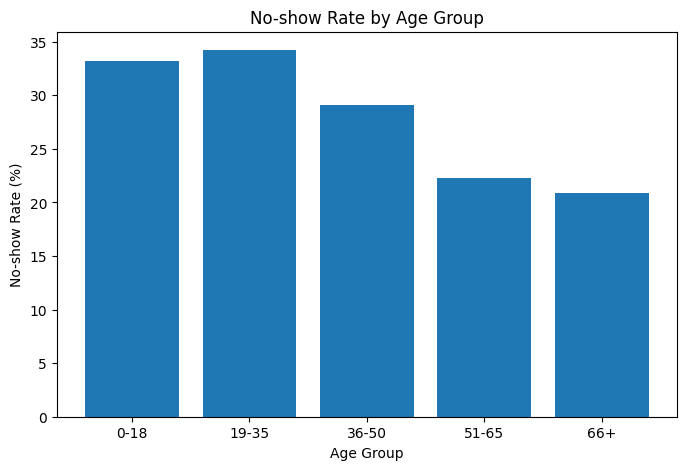

In [51]:
import matplotlib.pyplot as plt

# Bar chart showing no-show rate across different age groups
plt.figure(figsize=(8, 5))
plt.bar(age_no_show["AgeGroup"], age_no_show["No_show_rate"])
plt.xlabel("Age Group")
plt.ylabel("No-show Rate (%)")
plt.title("No-show Rate by Age Group")
plt.show()

In [52]:
# Compare no-show rates between patients who received an SMS reminder and those who did not
sms_no_show = (
    df.groupby("SMS_received")["No_show"]
    .apply(lambda x: (x == "Yes").mean() * 100)
    .reset_index(name="No_show_rate")
)

# Replace 0/1 with readable labels
sms_no_show["SMS_received"] = sms_no_show["SMS_received"].map({
    0: "No SMS",
    1: "SMS Received"
})
sms_no_show

,SMS_received,No_show_rate
0,No SMS,29.407758
1,SMS Received,27.665973


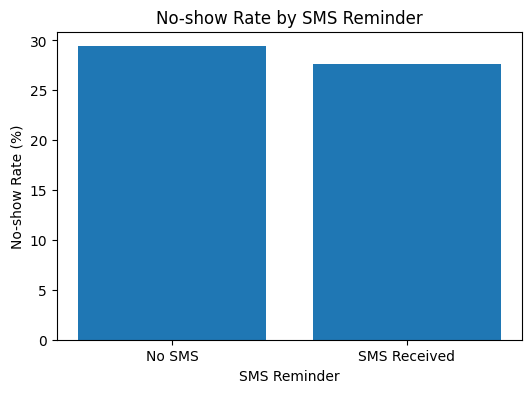

In [53]:
# Bar chart showing the effect of SMS reminders on no-show rate
plt.figure(figsize=(6, 4))
plt.bar(sms_no_show["SMS_received"], sms_no_show["No_show_rate"])
plt.xlabel("SMS Reminder")
plt.ylabel("No-show Rate (%)")
plt.title("No-show Rate by SMS Reminder")
plt.show()

In [54]:
# Ensure AppointmentDay is in datetime format, then extract the day of the week
df["AppointmentDay"] = pd.to_datetime(df["AppointmentDay"])
df["AppointmentWeekday"] = df["AppointmentDay"].dt.day_name()

# Count total no-shows per weekday
weekday_no_shows = (
    df[df["No_show"] == "Yes"]
    .groupby("AppointmentWeekday")
    .size()
    .sort_values(ascending=False)
)

weekday_no_shows

AppointmentWeekday
Tuesday      4604
Wednesday    4493
Monday       4240
Friday       3586
Thursday     2999
Saturday        9
dtype: int64

In [55]:
# Calculate the no-show rate (%) for each day of the week
weekday_no_show_rate = (
    df.groupby("AppointmentWeekday")["No_show"]
    .apply(lambda x: (x == "Yes").mean() * 100)
    .sort_values(ascending=False)
)

weekday_no_show_rate

AppointmentWeekday
Monday       30.028329
Friday       29.415142
Saturday     29.032258
Tuesday      28.773202
Thursday     27.440754
Wednesday    27.146396
Name: No_show, dtype: float64

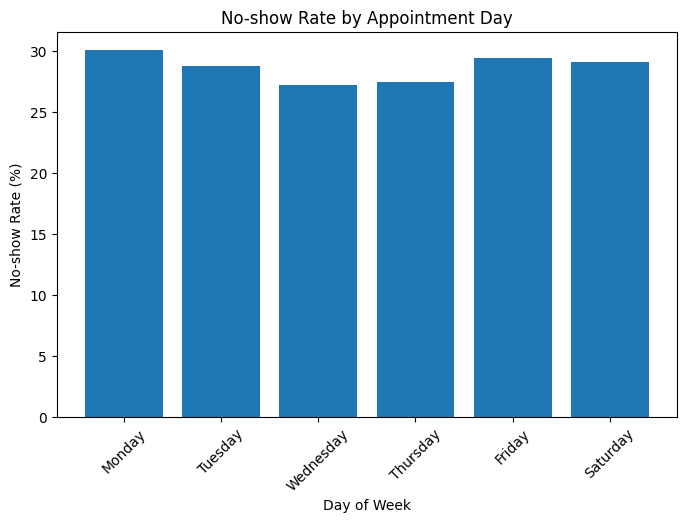

In [56]:
import matplotlib.pyplot as plt

# Reorder days into calendar order before plotting
weekday_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
weekday_no_show_rate = weekday_no_show_rate.reindex(weekday_order)

# Bar chart of no-show rate by day of the week
plt.figure(figsize=(8, 5))
plt.bar(weekday_no_show_rate.index, weekday_no_show_rate.values)
plt.xlabel("Day of Week")
plt.ylabel("No-show Rate (%)")
plt.title("No-show Rate by Appointment Day")
plt.xticks(rotation=45)
plt.show()

In [57]:
# Calculate no-show rate for patients with and without each health condition
health_cols = ["Hypertension", "Diabetes", "Alcoholism", "Handicap"]

for col in health_cols:
    print(f"\nNo-show rate by {col}:")
    print(
        df.groupby(col)["No_show"]
        .apply(lambda x: (x == "Yes").mean() * 100)
    )
print('0 = does not have condition, 1 = has condition')


No-show rate by Hypertension:
Hypertension
0    29.922251
1    23.524716
Name: No_show, dtype: float64

No-show rate by Diabetes:
Diabetes
0    28.844304
1    24.958155
Name: No_show, dtype: float64

No-show rate by Alcoholism:
Alcoholism
0    28.396641
1    34.083425
Name: No_show, dtype: float64

No-show rate by Handicap:
Handicap
0    28.605204
1    24.873096
2    30.357143
3    25.000000
4    50.000000
Name: No_show, dtype: float64
0 = does not have condition ,1 = has condition


In [58]:
# Build a summary table comparing no-show rates for each health condition
health_summary = []

for col in health_cols:
    no_condition_rate = df[df[col] == 0]["No_show"].eq("Yes").mean() * 100
    condition_rate = df[df[col] == 1]["No_show"].eq("Yes").mean() * 100
    
    health_summary.append({
        "Condition": col,
        "No condition no-show rate (%)": no_condition_rate,
        "Has condition no-show rate (%)": condition_rate
    })

health_summary = pd.DataFrame(health_summary)
health_summary

,Condition,No condition no-show rate (%),Has condition no-show rate (%)
0,Hypertension,29.922251,23.524716
1,Diabetes,28.844304,24.958155
2,Alcoholism,28.396641,34.083425
3,Handicap,28.605204,24.873096


In [59]:
# Feature engineering — create new columns to improve model performance

# Days between booking date and appointment date
df["WaitingDays"] = (
    df["AppointmentDay"].dt.normalize() - df["ScheduledDay"].dt.normalize()
).dt.days

# Day of week the appointment falls on
df["AppointmentWeekday"] = df["AppointmentDay"].dt.day_name()

# Month of the appointment
df["AppointmentMonth"] = df["AppointmentDay"].dt.month_name()

# Age group bands
bins = [0, 18, 35, 50, 65, 120]
labels = ["0-18", "19-35", "36-50", "51-65", "66+"]
df["AgeGroup"] = pd.cut(df["Age"], bins=bins, labels=labels, include_lowest=True)

# Convert target column to binary: 0 = attended, 1 = no-show
df["No_show_binary"] = df["No_show"].map({
    "No": 0,
    "Yes": 1
})

In [60]:
# Preview the new engineered columns alongside the original date columns
df[[
    "ScheduledDay",
    "AppointmentDay",
    "WaitingDays",
    "AppointmentWeekday",
    "AppointmentMonth",
    "Age",
    "AgeGroup",
    "No_show",
    "No_show_binary"
]].head()

,ScheduledDay,AppointmentDay,WaitingDays,AppointmentWeekday,AppointmentMonth,Age,AgeGroup,No_show,No_show_binary
5,2016-04-27 08:36:51+00:00,2016-04-29 00:00:00+00:00,2,Friday,April,76,66+,No,0
6,2016-04-27 15:05:12+00:00,2016-04-29 00:00:00+00:00,2,Friday,April,23,19-35,Yes,1
7,2016-04-27 15:39:58+00:00,2016-04-29 00:00:00+00:00,2,Friday,April,39,36-50,Yes,1
9,2016-04-27 12:48:25+00:00,2016-04-29 00:00:00+00:00,2,Friday,April,19,19-35,No,0
10,2016-04-27 14:58:11+00:00,2016-04-29 00:00:00+00:00,2,Friday,April,30,19-35,No,0


In [63]:
# Define the target variable (what we want to predict)
y = df["No_show_binary"]

# Select the features (inputs) the model will learn from
features = [
    "Gender",
    "Age",
    "WaitingDays",
    "SMS_received",
    "Hypertension",
    "Diabetes",
    "Alcoholism",
    "Handicap",
    "AppointmentWeekday",
    "AppointmentMonth"
]

X = df[features]

# One-hot encode categorical columns (Gender, Weekday, Month) into numeric columns
X = pd.get_dummies(X, drop_first=True)

# Split into 80% training data and 20% test data
# stratify=y ensures both splits have the same proportion of no-shows
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [65]:
# Train baseline models without any class balancing
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(random_state=42)
}

results = []

# Train each model, make predictions, and record performance metrics
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred)
    })

results_df = pd.DataFrame(results)
results_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.714357,0.363636,0.001004,0.002002
1,Random Forest,0.652417,0.348569,0.250627,0.291594


In [67]:
# Generate class predictions on the test set using the last trained model
y_pred = model.predict(X_test)

In [66]:
# Get the predicted probability of no-show for each appointment
# [:, 1] selects the probability of the positive class (no-show = 1)
y_proba = model.predict_proba(X_test)[:, 1]

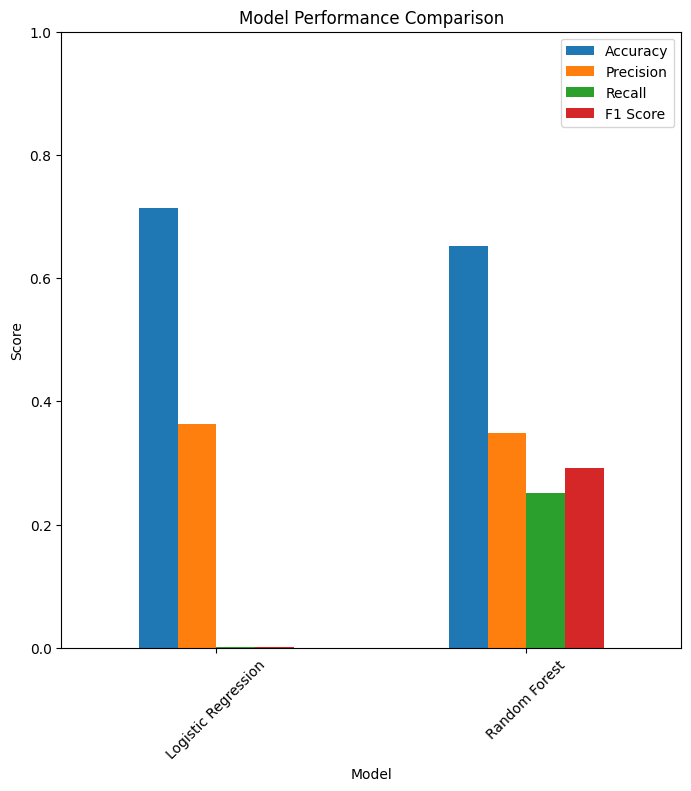

In [68]:
# Bar chart comparing all four metrics across both models (before balancing)
results_df.set_index("Model").plot(kind="bar", figsize=(8, 8))

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=45)
plt.show()

In [69]:
# Re-train both models with class_weight='balanced'
# This corrects for the imbalance between attended (80%) and no-show (20%) patients
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

logistic_model = LogisticRegression(class_weight='balanced', max_iter=1000)
random_forest_model = RandomForestClassifier(class_weight='balanced', random_state=42)

models = {
    "Logistic Regression": logistic_model,
    "Random Forest": random_forest_model
}

results = []

# Train, predict, and evaluate both balanced models
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred)
    })

results_df = pd.DataFrame(results)
results_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.559040,0.339634,0.577020,0.427589
1,Random Forest,0.625636,0.331798,0.307326,0.319094


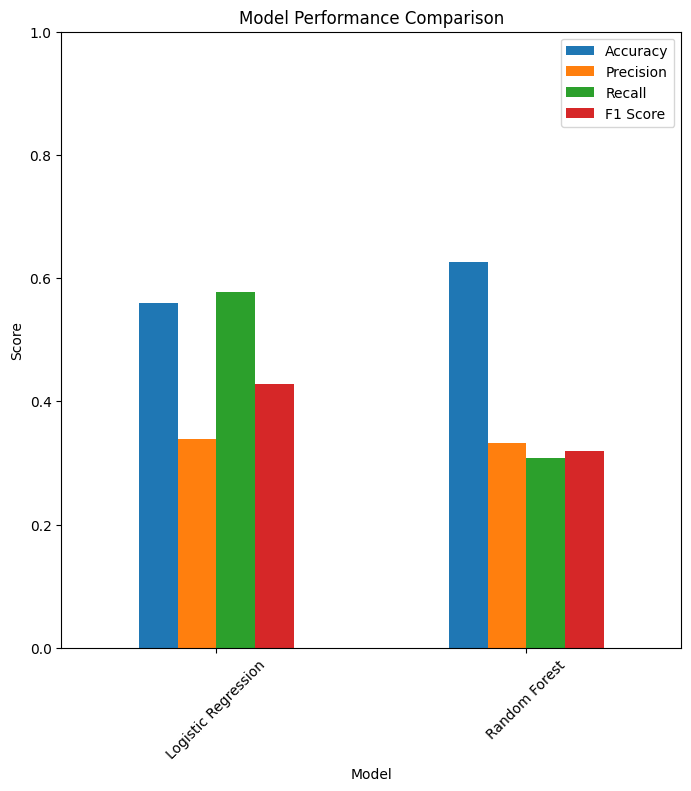

In [70]:
# Bar chart comparing metrics after applying class balancing
results_df.set_index("Model").plot(kind="bar", figsize=(8, 8))

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=45)
plt.show()

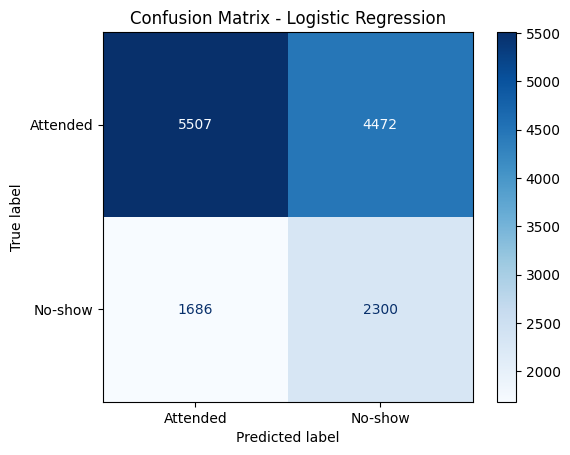

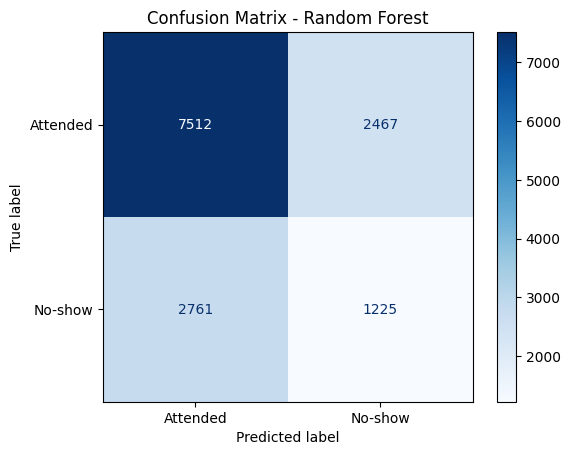

In [71]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

models = {
    "Logistic Regression": logistic_model,
    "Random Forest": random_forest_model
}

# Plot a confusion matrix for each model
# Shows true positives, false positives, true negatives, false negatives
for name, model in models.items():
    y_pred = model.predict(X_test)

    cm = confusion_matrix(y_test, y_pred)

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["Attended", "No-show"]
    )

    disp.plot(cmap="Blues")
    plt.title(f"Confusion Matrix - {name}")
    plt.savefig("confusion_matrix_logistic_regression.png", dpi=300, bbox_inches="tight")
    plt.show()

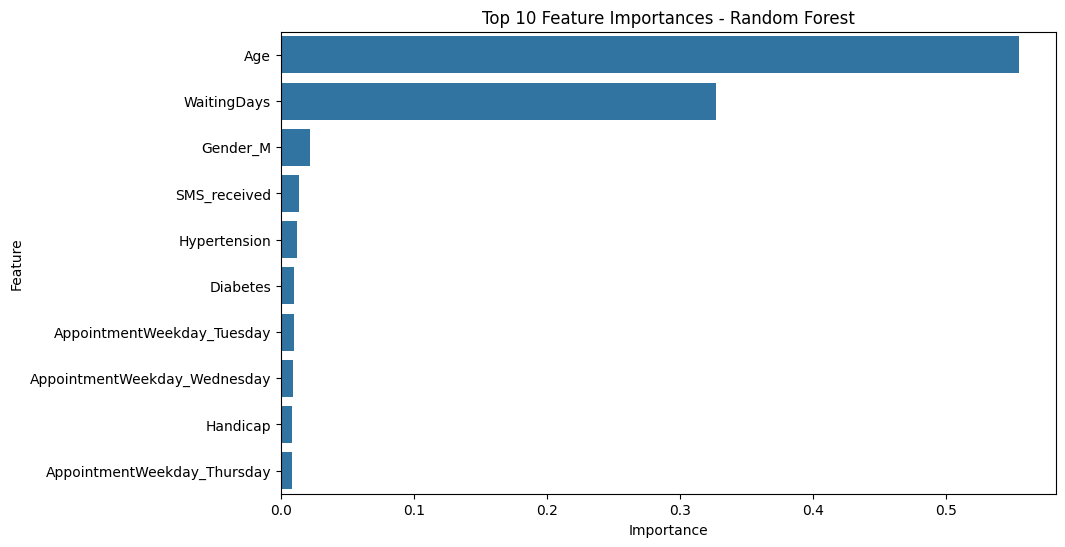

In [72]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Build a DataFrame of feature importances from the Random Forest model
# Higher importance = stronger influence on predictions
importance_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": random_forest_model.feature_importances_
})

importance_df = importance_df.sort_values(by="Importance", ascending=False)

# Bar chart of the top 10 most important features
plt.figure(figsize=(10, 6))
sns.barplot(data=importance_df.head(10), x="Importance", y="Feature")

plt.title("Top 10 Feature Importances - Random Forest")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.savefig("feature_importance_random_forest.png", dpi=300, bbox_inches="tight")
plt.show()

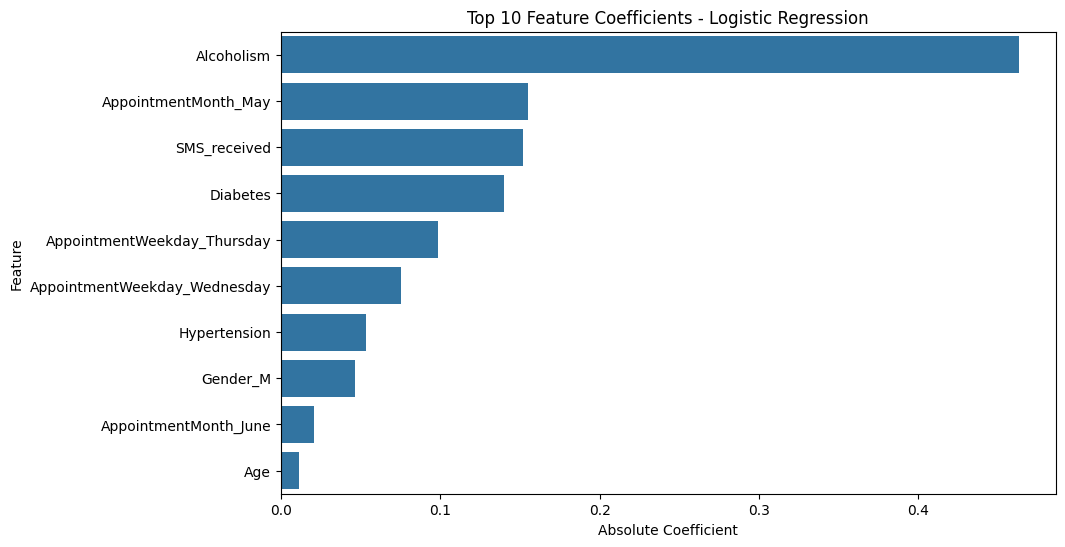

In [76]:
# Build a DataFrame of Logistic Regression coefficients
# Positive coefficient = increases no-show probability
# Negative coefficient = decreases no-show probability
coef_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": logistic_model.coef_[0]
})

# Use absolute value to rank by strength regardless of direction
coef_df["Absolute_Coefficient"] = coef_df["Coefficient"].abs()

coef_df = coef_df.sort_values(by="Absolute_Coefficient", ascending=False)

# Bar chart of the top 10 most influential features
plt.figure(figsize=(10, 6))
sns.barplot(data=coef_df.head(10), x="Absolute_Coefficient", y="Feature")

plt.title("Top 10 Feature Coefficients - Logistic Regression")
plt.xlabel("Absolute Coefficient")
plt.ylabel("Feature")

plt.savefig("feature_coefficients_logistic_regression.png", dpi=300, bbox_inches="tight")
plt.show()

In [77]:
# Table view of the top 10 Logistic Regression coefficients
# Sorted by absolute value so the most influential features appear first
coef_table = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": logistic_model.coef_[0]
})

coef_table["Absolute_Coefficient"] = coef_table["Coefficient"].abs()

coef_table = coef_table.sort_values(
    by="Absolute_Coefficient",
    ascending=False
)

coef_table.head(10)

,Feature,Coefficient,Absolute_Coefficient
5,Alcoholism,0.462990,0.462990
14,AppointmentMonth_May,0.154854,0.154854
2,SMS_received,-0.152074,0.152074
4,Diabetes,0.139883,0.139883
10,AppointmentWeekday_Thursday,-0.098587,0.098587
12,AppointmentWeekday_Wednesday,-0.075588,0.075588
3,Hypertension,-0.053508,0.053508
7,Gender_M,-0.046618,0.046618
13,AppointmentMonth_June,0.021145,0.021145
0,Age,-0.011662,0.011662


In [78]:
# Table view of the top 10 Random Forest feature importances
importance_table = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": random_forest_model.feature_importances_
})

importance_table = importance_table.sort_values(
    by="Importance",
    ascending=False
)

importance_table.head(10)

,Feature,Importance
0,Age,0.554495
1,WaitingDays,0.327213
7,Gender_M,0.021841
2,SMS_received,0.013447
3,Hypertension,0.012194
4,Diabetes,0.009746
11,AppointmentWeekday_Tuesday,0.009614
12,AppointmentWeekday_Wednesday,0.009356
6,Handicap,0.008662
10,AppointmentWeekday_Thursday,0.008563
